predict (before training) 4 4.0
epoch: 0 w= 1.0933333333333333 loss= 4.666666666666667
epoch: 1 w= 1.1779555555555554 loss= 3.8362074074074086
epoch: 2 w= 1.2546797037037036 loss= 3.1535329869958857
epoch: 3 w= 1.3242429313580246 loss= 2.592344272332262
epoch: 4 w= 1.3873135910979424 loss= 2.1310222071581117
epoch: 5 w= 1.4444976559288012 loss= 1.7517949663820642
epoch: 6 w= 1.4963445413754464 loss= 1.440053319920117
epoch: 7 w= 1.5433523841804047 loss= 1.1837878313441108
epoch: 8 w= 1.5859728283235668 loss= 0.9731262101573632
epoch: 9 w= 1.6246153643467005 loss= 0.7999529948031382
epoch: 10 w= 1.659651263674342 loss= 0.6575969151946154
epoch: 11 w= 1.6914171457314033 loss= 0.5405738908195378
epoch: 12 w= 1.7202182121298057 loss= 0.44437576375991855
epoch: 13 w= 1.7463311789976905 loss= 0.365296627844598
epoch: 14 w= 1.7700069356245727 loss= 0.3002900634939416
epoch: 15 w= 1.7914729549662791 loss= 0.2468517784170642
epoch: 16 w= 1.8109354791694263 loss= 0.2029231330489788
epoch: 17 w= 

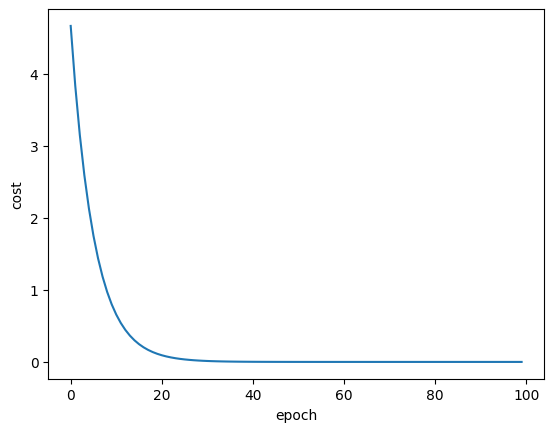

In [1]:
import matplotlib.pyplot as plt
 
# prepare the training set
x_data = [1.0, 2.0, 3.0]
y_data = [2.0, 4.0, 6.0]
 
# initial guess of weight 
w = 1.0
 
# define the model linear model y = w*x
def forward(x):
    return x*w
 
#define the cost function MSE 
def cost(xs, ys):
    # 计算损失函数,损失函数为均方误差
    cost = 0
    for x, y in zip(xs,ys):
        y_pred = forward(x)
        cost += (y_pred - y)**2
    return cost / len(xs)
 
# define the gradient function  gd
def gradient(xs,ys):
    # 计算梯度,梯度为均方误差的导数,损失函数对w的偏导数
    grad = 0
    for x, y in zip(xs,ys):
        grad += 2*x*(x*w - y)
    return grad / len(xs)
 
epoch_list = []
cost_list = []
print('predict (before training)', 4, forward(4))    # 预测值,预测值为4*w
for epoch in range(100):
    cost_val = cost(x_data, y_data)
    grad_val = gradient(x_data, y_data)
    w-= 0.01 * grad_val  # 0.01 learning rate
    print('epoch:', epoch, 'w=', w, 'loss=', cost_val)
    epoch_list.append(epoch)
    cost_list.append(cost_val)
 
print('predict (after training)', 4, forward(4))
plt.plot(epoch_list,cost_list)
plt.ylabel('cost')
plt.xlabel('epoch')
plt.show() 

### Stochastic Gradient Descent

#### 什么是随机梯度下降（SGD）

**梯度下降**是在找使损失 \(L($\theta$)\) 最小的参数 \($\theta$\) 时，沿着**负梯度**方向一步步更新：

\[
$\theta \leftarrow \theta - \eta \nabla_\theta L(\theta)$
\]

这里的差别主要在于：**这个梯度是对谁、对多少数据算的**。

- **批量梯度下降（Batch GD）**  
  每一步用**全体训练样本**算损失，再对全体样本求平均梯度：  
  \($\nabla L(\theta) = \frac{1}{N}\sum_{i=1}^N \nabla \ell_i(\theta)$\)  
  一步更新要等“看完一遍全数据”。

- **随机梯度下降（SGD，经典含义）**  
  每一步只**随机抽一个样本** \(i\)，用这一条样本上的梯度近似整体梯度：  
  \($\theta \leftarrow \theta - \eta \nabla \ell_i(\theta)$\)  
  “随机”指的就是：**每次参与更新的样本是随机选的**，所以梯度是**有噪声的、对真实整体梯度的随机估计**。

- **小批量随机梯度下降（Mini-batch SGD）**（深度学习和大多数库里常说的 “SGD”）  
  每一步用**一小批**（例如 32、128）样本算平均梯度，在**计算量**和**梯度噪声**之间折中。理论和实践里，它仍常被称为 SGD，因为相对全批量仍是“随机抽样”的。

所以：**随机梯度下降 = 用“子集/单样本”上的梯度，加上抽样带来的随机性，来做参数更新**。

---

#### 为什么要采用随机梯度下降

1. **当 \(N\) 很大时，全批量太贵**  
   全数据前向、反向各一遍才算一步，数据量上百万时，一步可能就要很久。**随机或小批量**让每一步只处理少量数据，**单位时间内能走更多步**，总体往往更快收敛到可用解。

2. **内存与工程上的可行**  
   全批量要把所有样本放进一次计算（或很大的中间结果），GPU/内存可能放不下。**小批量**把问题切小块，更适合现代硬件和并行。

3. **噪声有时反而是好事**  
   单样本或小批量的梯度是**有偏、有方差**的估计。这种噪声会带来**轻微抖动**，有助于：
   - 在**较平坦或鞍点**附近不容易完全卡死；
   - 在一定程度上起到**类似正则**的效果，有时泛化不差于特别“干净”的全批量轨迹（视问题与超参而定）。

4. **在线 / 流式学习**  
   数据是**一条条到达**、不能一次性读全盘时，自然只能按样本或小流更新，这和 SGD 的思路一致。

5. **和深度学习的规模匹配**  
   深层网络全批量一步太慢；**小批量 SGD + 动量 / Adam 等**是工业界和科研里最主流的优化范式之一。

---

#### 小结

| 角度 | 批量 GD | 随机 / 小批量 SGD |
|------|---------|-------------------|
| 每步用到的数据 | 全部 | 一个或一小批（随机） |
| 梯度 | 准确、平滑 | 有噪声 |
| 单步成本 | 高（数据大时） | 低 |
| 典型场景 | 小数据、理论演示 | 大数据、深度学习 |

**一句话**：随机梯度下降用**随机子集上的梯度**代替**全数据梯度**，主要为了在**大模型、大数据**下让优化在**时间、内存上可承受**；随机性带来的**噪声**在实践里也常带来**优化与泛化上的好处**。若你正在写 `gradient_descent.ipynb`，可以把“全批量一步”和“按 batch 一步”的更新公式并排写在笔记里，会更容易和代码对应起来。

predict (before training) 4 4.0
	grad: 1.0 2.0 -2.0 w= 1.02
	grad: 2.0 4.0 -7.84 w= 1.0984
	grad: 3.0 6.0 -16.2288 w= 1.260688
progress: 0 w= 1.260688 loss= 4.919240100095999
	grad: 1.0 2.0 -1.478624 w= 1.27547424
	grad: 2.0 4.0 -5.796206079999999 w= 1.3334363008
	grad: 3.0 6.0 -11.998146585599997 w= 1.453417766656
progress: 1 w= 1.453417766656 loss= 2.688769240265834
	grad: 1.0 2.0 -1.093164466688 w= 1.4643494113228799
	grad: 2.0 4.0 -4.285204709416961 w= 1.5072014584170494
	grad: 3.0 6.0 -8.87037374849311 w= 1.5959051959019805
progress: 2 w= 1.5959051959019805 loss= 1.4696334962911515
	grad: 1.0 2.0 -0.8081896081960389 w= 1.603987091983941
	grad: 2.0 4.0 -3.1681032641284723 w= 1.6356681246252256
	grad: 3.0 6.0 -6.557973756745939 w= 1.701247862192685
progress: 3 w= 1.701247862192685 loss= 0.8032755585999681
	grad: 1.0 2.0 -0.59750427561463 w= 1.7072229049488312
	grad: 2.0 4.0 -2.3422167604093502 w= 1.7306450725529248
	grad: 3.0 6.0 -4.848388694047353 w= 1.7791289594933983
progress: 4 

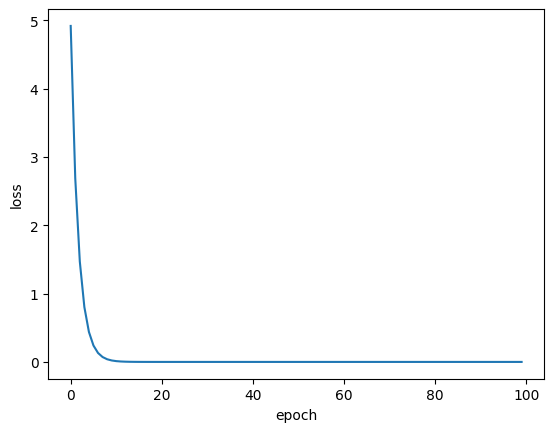

In [3]:
import matplotlib.pyplot as plt
 
x_data = [1.0, 2.0, 3.0]
y_data = [2.0, 4.0, 6.0]
 
w = 1.0
 
def forward(x):
    return x*w
 
# calculate loss function
def loss(x, y):
    y_pred = forward(x)
    return (y_pred - y)**2
 
# define the gradient function  sgd
# 随机梯度下降：不需要求所有样本的均值,只需要求一个样本的梯度
def gradient(x, y):
    return 2*x*(x*w - y)
 
epoch_list = []
loss_list = []
print('predict (before training)', 4, forward(4))
for epoch in range(100):
    for x,y in zip(x_data, y_data):
        grad = gradient(x,y)
        w = w - 0.01*grad    # update weight by every grad of sample of training set
        print("\tgrad:", x, y,grad, "w=",w)
        l = loss(x,y)
    print("progress:",epoch,"w=",w,"loss=",l)
    epoch_list.append(epoch)
    loss_list.append(l)
 
print('predict (after training)', 4, forward(4))
plt.plot(epoch_list,loss_list)
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show() 